# Notebook 01: Treinamento do Classificador de Categoria de Despesas

Este notebook tem como objetivo treinar um modelo de Machine Learning capaz de classificar descrições textuais de transações (ex: "Ifood", "Posto Shell") em categorias financeiras pré-definidas (`alimentacao`, `transporte`, `lazer`, etc.).

In [ ]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
# ==========================================================
# PATHS LOCAIS
# ==========================================================

BASE = "../../data"
BASE_MODELS = "../../models"

In [ ]:
# ==========================================================
# LEITURA DO DATASET
# ==========================================================

dataset_categoria = pd.read_csv(
    f"{BASE}/processed/dataset_modelo_categoria.csv"
)

dataset_categoria.head()

,descricao_transacao,valor_transacao,categoria
0,Compra online - Burger King (compra à vista),829.09,Alimentação
1,Transação - Renner (parcelado em 4x),232.37,Compras
2,Consumo em CDB Banco Inter (compra à vista),910.31,Investimentos
3,Débito - Decolar.com,421.92,Lazer
4,Pagamento de conta - Açougue Central,450.77,Alimentação


In [ ]:
# ==========================================================
# PREPARACAO E VARIAVEIS
# ==========================================================

COLUNAS_OBRIGATORIAS = {"descricao_transacao", "valor_transacao", "categoria"}
faltantes = COLUNAS_OBRIGATORIAS - set(dataset_categoria.columns)
if faltantes:
    raise ValueError(f"Colunas obrigatorias ausentes: {faltantes}")

dataset_categoria = dataset_categoria.dropna(subset=COLUNAS_OBRIGATORIAS).copy()
dataset_categoria["descricao_transacao"] = dataset_categoria["descricao_transacao"].astype(str).str.strip()
dataset_categoria["valor_transacao"] = pd.to_numeric(dataset_categoria["valor_transacao"], errors="coerce")
dataset_categoria = dataset_categoria.dropna(subset=["valor_transacao"])

X_texto = dataset_categoria["descricao_transacao"]
X_valor = dataset_categoria["valor_transacao"].astype(float)
y = dataset_categoria["categoria"]

print(f"Registros para treino: {len(dataset_categoria):,}")
print(f"Categorias: {y.nunique()}")
display(y.value_counts().rename_axis("categoria").to_frame("quantidade"))

In [ ]:
# ==========================================================
# DIVISAO E TF-IDF SEM VAZAMENTO
# ==========================================================

# A separacao acontece antes do fit do vetorizer para que o vocabulario
# do conjunto de teste nao influencie o treinamento.
X_texto_train, X_texto_test, X_valor_train, X_valor_test, y_train, y_test = train_test_split(
    X_texto, X_valor, y, test_size=0.20, random_state=42, stratify=y
)

PARAMETROS_TFIDF = {
    "lowercase": True,
    "strip_accents": "unicode",
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.98,
    "sublinear_tf": True
}

tfidf = TfidfVectorizer(**PARAMETROS_TFIDF)
X_texto_train_tfidf = tfidf.fit_transform(X_texto_train)
X_texto_test_tfidf = tfidf.transform(X_texto_test)
print(f"Vocabulario aprendido apenas no treino: {len(tfidf.vocabulary_):,} termos")

In [ ]:
# ==========================================================
# CONCATENACAO DA FEATURE NUMERICA
# ==========================================================

from scipy.sparse import hstack

X_train = hstack([X_texto_train_tfidf, X_valor_train.to_numpy().reshape(-1, 1)])
X_test = hstack([X_texto_test_tfidf, X_valor_test.to_numpy().reshape(-1, 1)])

In [ ]:
# ==========================================================
# CHECAGEM DA DIVISAO E DO BALANCEAMENTO
# ==========================================================

proporcoes = pd.concat(
    [y_train.value_counts(normalize=True).rename("treino"), y_test.value_counts(normalize=True).rename("teste")],
    axis=1
).fillna(0)
display(proporcoes)

In [ ]:
# ==========================================================
# TREINAMENTO DO MODELO
# ==========================================================

# ComplementNB reduz o viés para as classes mais frequentes e preserva
# predict_proba, utilizado pelo contrato da API.
modelo_categoria = ComplementNB(alpha=0.2)
modelo_categoria.fit(X_train, y_train)

MultinomialNB()

In [ ]:
# ==========================================================
# PREDICAO
# ==========================================================

predicoes = modelo_categoria.predict(X_test)

In [ ]:
# ==========================================================
# METRICAS DE AVALIACAO
# ==========================================================

accuracy = accuracy_score(y_test, predicoes)
precision = precision_score(y_test, predicoes, average="macro")
recall = recall_score(y_test, predicoes, average="macro")
f1 = f1_score(y_test, predicoes, average="macro", zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# F1 macro e a metrica principal: cada categoria tem o mesmo peso,
# inclusive as menos frequentes.

Accuracy : 0.9838
Precision: 0.9860
Recall   : 0.9826
F1-Score : 0.9836


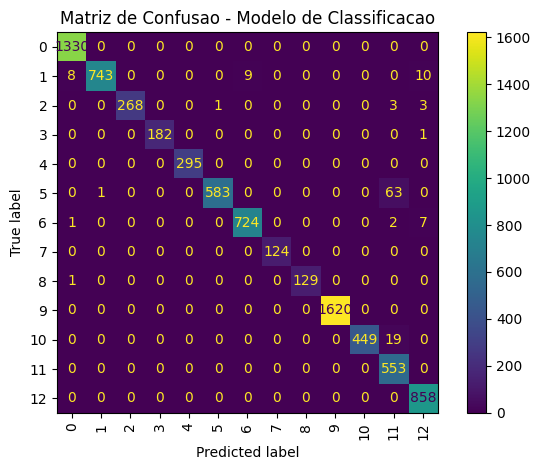

In [ ]:
# ==========================================================
# MATRIZ DE CONFUSAO
# ==========================================================

import matplotlib.pyplot as plt

classes = sorted(y.unique())
cm = confusion_matrix(y_test, predicoes, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

disp.plot(xticks_rotation=90)
plt.title("Matriz de Confusao - Modelo de Classificacao")
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# RELATORIO DE CLASSIFICACAO
# ==========================================================

print(classification_report(y_test, predicoes, labels=sorted(y.unique()), digits=4, zero_division=0))

               precision    recall  f1-score   support

  Alimentação     0.9925    1.0000    0.9963      1330
      Compras     0.9987    0.9649    0.9815       770
     Educação     1.0000    0.9745    0.9871       275
     Impostos     1.0000    0.9945    0.9973       183
Investimentos     1.0000    1.0000    1.0000       295
        Lazer     0.9983    0.9011    0.9472       647
      Moradia     0.9877    0.9864    0.9870       734
       Outros     1.0000    1.0000    1.0000       124
         Pets     1.0000    0.9923    0.9961       130
     Receitas     1.0000    1.0000    1.0000      1620
        Saúde     1.0000    0.9594    0.9793       468
     Serviços     0.8641    1.0000    0.9271       553
   Transporte     0.9761    1.0000    0.9879       858

     accuracy                         0.9838      7987
    macro avg     0.9860    0.9826    0.9836      7987
 weighted avg     0.9854    0.9838    0.9840      7987



In [ ]:
# ==========================================================
# RETREINO FINAL E EXPORTACAO DOS ARTEFATOS
# ==========================================================

import os

# A avaliacao acima usa somente 80% dos dados. Depois de aprovada,
# treinamos novamente com todos os registros para o artefato de producao.
tfidf = TfidfVectorizer(**PARAMETROS_TFIDF)
X_texto_final = tfidf.fit_transform(X_texto)
X_final = hstack([X_texto_final, X_valor.to_numpy().reshape(-1, 1)])
modelo_categoria = ComplementNB(alpha=0.2)
modelo_categoria.fit(X_final, y)

os.makedirs(BASE_MODELS, exist_ok=True)
joblib.dump(modelo_categoria, f"{BASE_MODELS}/modelo_categoria.joblib")
joblib.dump(tfidf, f"{BASE_MODELS}/tfidf.joblib")

print("Modelo e vetorizador exportados para producao com sucesso.")

Modelo de classificacao treinado com sucesso.


In [ ]:
# ==========================================================
# VALIDACAO CRUZADA
# ==========================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

# O TF-IDF e ajustado novamente em cada fold, evitando que o vocabulario
# das particoes de validacao vaze para o treino.
for indices_treino, indices_validacao in cv.split(X_texto, y):
    texto_treino = X_texto.iloc[indices_treino]
    texto_validacao = X_texto.iloc[indices_validacao]
    valor_treino = X_valor.iloc[indices_treino].to_numpy().reshape(-1, 1)
    valor_validacao = X_valor.iloc[indices_validacao].to_numpy().reshape(-1, 1)

    tfidf_fold = TfidfVectorizer(**PARAMETROS_TFIDF)
    X_treino_fold = hstack([tfidf_fold.fit_transform(texto_treino), valor_treino])
    X_validacao_fold = hstack([tfidf_fold.transform(texto_validacao), valor_validacao])

    modelo_fold = ComplementNB(alpha=0.2)
    modelo_fold.fit(X_treino_fold, y.iloc[indices_treino])
    predicoes_fold = modelo_fold.predict(X_validacao_fold)
    scores.append(f1_score(y.iloc[indices_validacao], predicoes_fold, average="macro", zero_division=0))

scores = np.array(scores)

print("========== Validacao Cruzada ==========")
print(f"F1 Macro por Fold: {scores}")
print(f"F1 Macro Medio: {scores.mean():.4f}")
print(f"Desvio Padrao: {scores.std():.4f}")

========== Validacao Cruzada ==========
F1 Macro por Fold: [0.98301676 0.98090856 0.98180682 0.97946777 0.98012965]
F1 Macro Medio: 0.9811
Desvio Padrao: 0.0012


## Conclusao

O treinamento usa uma separacao estratificada antes do ajuste do TF-IDF, evitando vazamento do vocabulario do conjunto de teste. O modelo Complement Naive Bayes utiliza unigramas e bigramas, avalia F1 macro por categoria e executa validacao cruzada com um novo vetorizador em cada fold. Apos a avaliacao, os artefatos de producao sao retreinados com todos os dados e exportados como `modelo_categoria.joblib` e `tfidf.joblib`, no formato esperado pela API.